In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy
import Corrfunc

from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
odir = "../../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk10 = pickle.load(f)

In [4]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [5]:
def cf_lin_w_bias(r, bias=1,R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_lin(r)
    return cf

In [6]:
def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

In [7]:
def cf_lin_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_lin(r)
    cf[mask] = -1
    return cf

In [8]:
def cf_nl_excl(r, bias=1, R=0.15):
    d = 2*R
    mask = r < d
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    cf[mask] = -1
    return cf

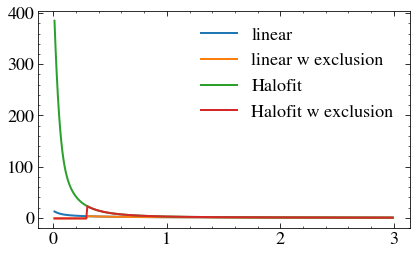

In [9]:
r = np.arange(0.01,3, 0.01)

plt.plot(r, cf_lin(r), label="linear")
plt.plot(r, cf_lin_excl(r), label="linear w exclusion")
plt.plot(r, cf_nl(r), label="Halofit")
plt.plot(r, cf_nl_excl(r), label="Halofit w exclusion")
plt.legend()

(-1.1, 50.0)

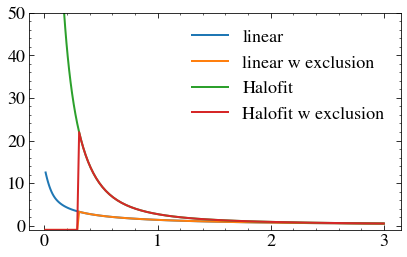

In [13]:
rmin = 0.01
rmax = 3.0
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)


plt.plot(rbins, cf_lin(rbins), label="linear")
plt.plot(rbins, cf_lin_excl(rbins), label="linear w exclusion")
plt.plot(rbins, cf_nl(rbins), label="Halofit")
plt.plot(rbins, cf_nl_excl(rbins), label="Halofit w exclusion")
plt.legend()
plt.ylim(-1.1,50)

In [10]:
tng_dir = "/cosma7/data/dp004/dc-zhan5/TNG/snap40/SubhaloFlag_all/mvir/ihalo"
tng_data = np.loadtxt(f"{tng_dir}/sfr-halomass_sum.txt")
mhalo_tng = tng_data[:,1]
pos_tng = tng_data[:,2:5]
sfr_tng = tng_data[:,5]


In [11]:
mask = mhalo_tng > 10
mhalo_tng = mhalo_tng[mask]
pos_tng = pos_tng[mask]
sfr_tng = sfr_tng[mask]

In [14]:
from Corrfunc.theory import xi

boxsize=205

results = xi(boxsize, 2, rbins , pos_tng[:,0],pos_tng[:,1],pos_tng[:,2], 
             weights=None,output_ravg=True)

(-2.0, 20.0)

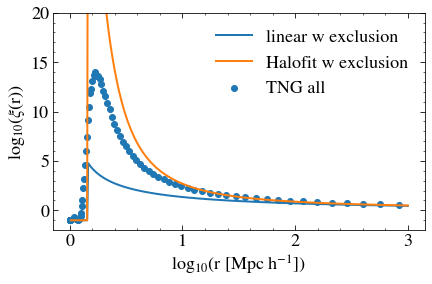

In [17]:
plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.plot(rbins, cf_lin_excl(rbins, R=0.08), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, R=0.08), label="Halofit w exclusion")

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"log$_{10}$($\xi$(r))")
plt.legend()
plt.ylim(-2,20)

#### Try adding lognormal distribution

In [19]:
dlogk = 0.1
logkmin = -1.5
logkmax = 1.5
Nk = int( (logkmax - logkmin) / dlogk )
logks = [ logkmin + dlogk * i for i in range(Nk) ]
dr = 0.1
rmax = 3
Nr = int( rmax / dr )
print(Nr)
r_list = np.array([ dr * (i+1) for i in range(Nr) ])

# def lognormal(logk_list, xi_c, sigma, R):
#     #dr = 0.00003
    

#     k_list = [ 10 ** logk for logk in logk_list ]

#     prefactor = - dr * 4. * np.pi
#     for i, k in enumerate(k_list):
#         x = np.log10(r_list / R) / (np.sqrt(2) * sigma)
#         fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
#         if sigma == 0:
#             xi_d = xi_c(r_list, R)
#         else:
#             xi_d = (1 - fr) * (xi_c(r_list, R) + 1) - 1

#         sin_term = np.sin(k * r_list) / (k * r_list)
#         #Pk[i] = np.sum(prefactor * i *  r_list**2 * sin_term * xi_d)

#         if i == 0:
#             fr_list = fr
#             cf_list = xi_d

#     return cf_list#, Pk


def lognormal_cf(xi_c, sigma, R,bias=1, rmax=3, dr=0.1):
    #dr = 0.00003
    Nr = int( rmax / dr )
  
    r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return xi_d

#     for sigma in [sigma]:
#         Pk = np.zeros(Nk)

#         fr_list = []
#         cf_list = []
#         for i, k in enumerate(k_list):
#             for r in r_list:
#                 x = np.log10( r / R ) / np.sqrt(2) / sigma
#                 fr = 1 - 0.5 * ( 1. + scipy.special.erf(x) )
#                 xi_d = (1-fr)*(xi_c(r, R) + 1) - 1
#                 if sigma == 0:
#                     fr = 1
#                 Pk[i] += - dr * 4. * np.pi * r**2 * np.sin(k * r) / (k * r) * xi_d
#                 if i == 0:
#                     fr_list.append(fr)
#                     cf_list.append(xi_d)

#     #plt.plot(np.array(r_list), np.array(fr_list))
#     return cf_list, Pk



30


In [78]:
cf_list, Pk = lognormal(logks, cf_lin_excl, sigma=0.1, R=0.2)

In [79]:
cf_nl001, Pk_nl001 = lognormal(logks, cf_nl_excl, sigma=0.1, R=0.2)

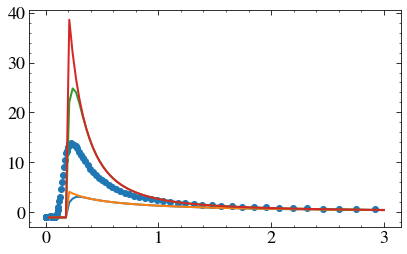

In [80]:
plt.plot(r_list, cf_list)
plt.plot(r_list, cf_lin_excl(np.array(r_list),R=0.2))
plt.plot(r_list, cf_nl001)


plt.plot(r_list, cf_nl_excl(np.array(r_list),R=0.2))


plt.scatter(results["ravg"], results["xi"], label="TNG all")


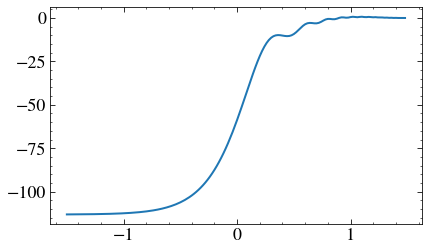

In [84]:
plt.plot(logks, Pk_nl001)

In [200]:
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=0.8, sigma=0.1, R=0.1)

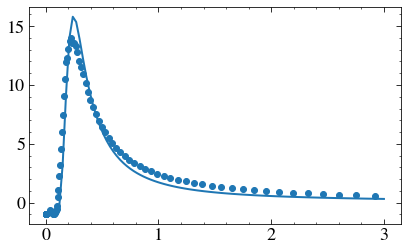

In [201]:
plt.scatter(results["ravg"], results["xi"], label="TNG all")

plt.plot(r_list, cf_nl01)

### Try for smaller mass range

In [153]:


mask11 = (mhalo_tng > 11) & (mhalo_tng < 11.1)
pos_tng11 = pos_tng[mask11]

results11 = xi(boxsize, 2, rbins , pos_tng11[:,0],pos_tng11[:,1],pos_tng11[:,2], 
             weights=None,output_ravg=True)

(-2.0, 20.0)

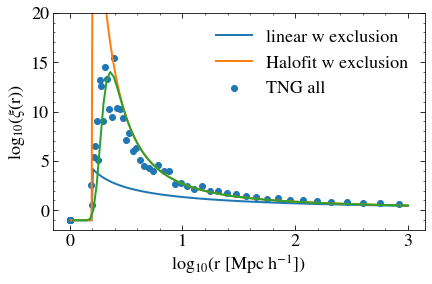

In [174]:
plt.scatter(results11["ravg"], results11["xi"], label="TNG all")
plt.plot(rbins, cf_lin_excl(rbins, R=0.1), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, R=0.1), label="Halofit w exclusion")
cf_nl01 = lognormal_cf(cf_nl_w_bias, sigma=0.08, R=0.15)
plt.plot(r_list, cf_nl01)

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"log$_{10}$($\xi$(r))")
plt.legend()
plt.ylim(-2,20)

In [66]:
mask11 = (mhalo_tng > 12) & (mhalo_tng < 12.5)
pos_tng12 = pos_tng[mask11]

results12 = xi(boxsize, 2, rbins , pos_tng12[:,0],pos_tng12[:,1],pos_tng12[:,2], 
             weights=None,output_ravg=True)

(-2.0, 20.0)

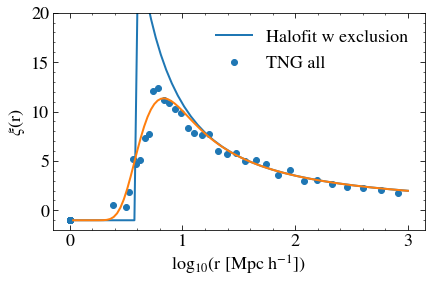

In [186]:
plt.scatter(results12["ravg"], results12["xi"], label="TNG all")
# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), label="Halofit w exclusion")
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.1, R=0.35)
plt.plot(r_list, cf_nl01)

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,20)

(-2.0, 20.0)

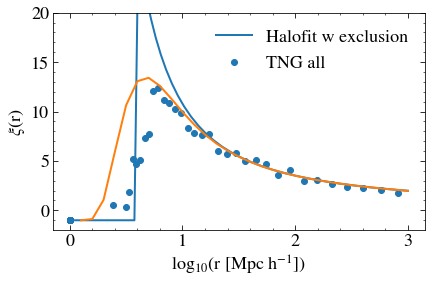

In [75]:
plt.scatter(results12["ravg"], results12["xi"], label="TNG all")
# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), label="Halofit w exclusion")
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.15, R=0.3)
plt.plot(r_list, cf_nl01)

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,20)

# Weighted correlation function

In [23]:
rmin = 0.01
rmax = 3
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)

In [33]:
len(pos_tng)

1093304

In [24]:
results_weighted = xi(boxsize, 2, rbins , pos_tng[:,0],pos_tng[:,1],pos_tng[:,2], 
             weights=10**sfr_tng,weight_type='pair_product',output_ravg=True)

In [35]:
import time
start_time = time.time()
results_test = xi(boxsize, 2, rbins , pos_tng[:,0],pos_tng[:,1],pos_tng[:,2], 
             output_ravg=True)
end_time = time.time()
print(end_time-start_time)

1.1322546005249023


In [32]:
len(sfr_tng)

1093304

(-2.0, 30.0)

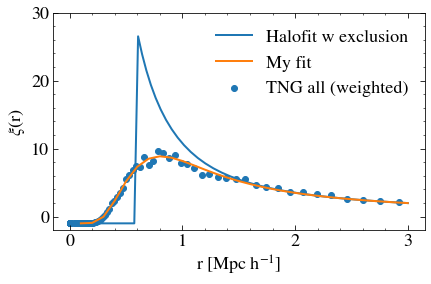

In [41]:
#plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label="TNG all (weighted)")

# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), label="Halofit w exclusion")
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.17, R=0.37)
plt.plot(r_list, cf_nl01, label="My fit")

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
#plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.xlabel("r [Mpc h$^{-1}$]")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,30)
#plt.ylim(-2,10)

(-2.0, 20.0)

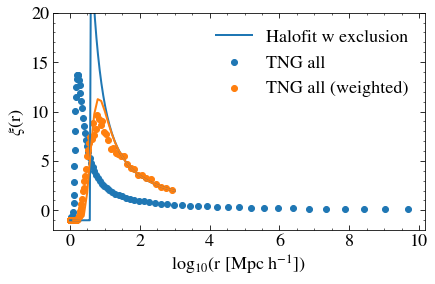

In [26]:
plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label="TNG all (weighted)")

# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), label="Halofit w exclusion")
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.1, R=0.35)
plt.plot(r_list, cf_nl01)

#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,20)

## Try to fit weighted one

(-2.0, 30.0)

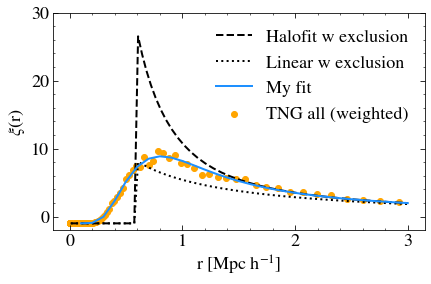

In [56]:
#plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label="TNG all (weighted)", c="orange")

# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), linestyle="dashed", c="k", label="Halofit w exclusion")

plt.plot(rbins, cf_lin_excl(rbins, bias=2, R=0.3), linestyle="dotted", c="k", label="Linear w exclusion")
# cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.15, R=0.35)
# plt.plot(r_list, cf_nl01)
# cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.2, R=0.4)
# plt.plot(r_list, cf_nl01)
# cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.18, R=0.38)
# plt.plot(r_list, cf_nl01)
cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.17, R=0.37)
plt.plot(r_list, cf_nl01, label="My fit", c="Dodgerblue")
#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("r [Mpc h$^{-1}$]")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,30)

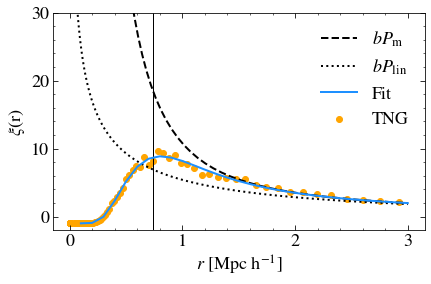

In [83]:
plt.vlines(0.37*2, ymin=-2, ymax=30, color="k", linewidth=1)
#plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label="TNG", c="orange")

# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_w_bias(rbins, bias=2), linestyle="dashed", c="k", label="$b P_{\mathrm{m}}$")

#plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), linestyle="dashed", c="grey", label="Halofit w exclusion")

#plt.plot(rbins, cf_lin_excl(rbins, bias=2, R=0.3), linestyle="dotted", c="grey", label="Linear w exclusion")
plt.plot(rbins, cf_lin_w_bias(rbins, bias=2), linestyle="dotted", c="k", label="$bP_{\mathrm{lin}}$")

cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.17, R=0.37)
plt.plot(r_list, cf_nl01, label="Fit", c="Dodgerblue")
#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("$r$ [Mpc h$^{-1}$]")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,30)
#plt.savefig("../../figures/cf_fit.pdf", format="pdf", bbox_inches="tight")

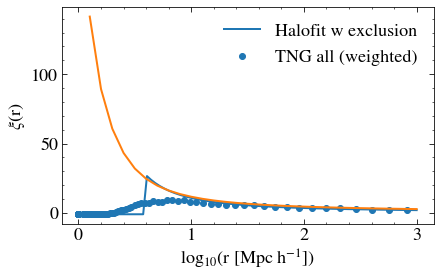

In [143]:
#plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label="TNG all (weighted)")

# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), label="Halofit w exclusion")

cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=3, sigma=1, R=0.5)
plt.plot(r_list, cf_nl01)
#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
#plt.ylim(-2,15)

In [144]:
def pk_from_cf_lin(logks):
    rmax = 1000
    dr=0.1
    r_list = np.arange(1e-4,rmax,dr)
    cf = cf_lin(r_list)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [145]:
def pk_from_cf_nl(logks):
    rmax = 1000
    dr=0.1
    r_list = np.arange(1e-4,rmax,dr)
    cf = cf_lin(r_list)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [47]:
Pk = pk_from_cf(logks, cf_lin)

(-10.0, 10.0)

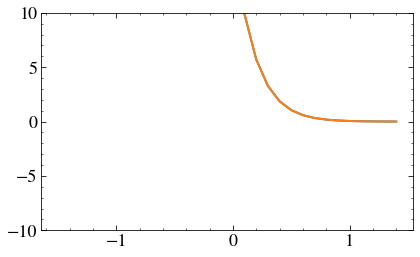

In [48]:
plt.plot(logks, Plin(10**np.array(logks)))
plt.plot(logks, Pk)
plt.ylim(-10,10)

In [49]:
def pk_from_cf(logks):
    rmax = 100
    dr=0.01
    r_list = np.arange(1e-4,rmax,dr)
    cf = lognormal_cf(cf_nl_w_bias, sigma=0.17, R=0.37, bias=2, rmax=rmax, dr=dr)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [ ]:
lin_sfr = 10**sfr_tng

In [26]:
rmax = 20
dr=0.1
r_list = np.arange(1e-4,rmax,dr)

results_weighted1 = xi(boxsize, 2, r_list , pos_tng[:,0],pos_tng[:,1],pos_tng[:,2], 
             weights=lin_sfr,weight_type='pair_product',output_ravg=True)

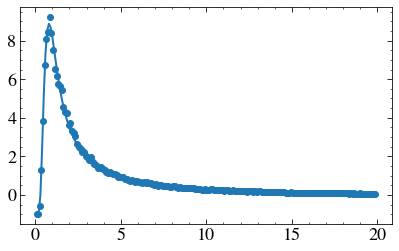

In [136]:

cf = lognormal_cf(cf_nl_w_bias, sigma=0.17, R=0.37, bias=2, rmax=rmax, dr=dr)
plt.scatter(results_weighted1["ravg"], results_weighted1["xi"], label="TNG all (weighted)")

plt.plot(r_list,cf)
#plt.ylim(-0.1,0.1)

In [84]:
Pk = pk_from_cf(logks)

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

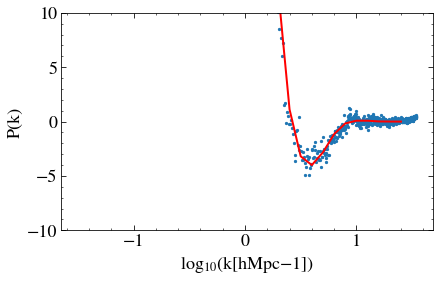

In [78]:

plt.scatter(np.log10(Pk10["k"]),Pk10["power"].real-Pk10.attrs["shotnoise"], s=5, label="Tot")
plt.plot(logks, Pk,c="red")
plt.ylim(-10,10)
plt.ylabel('P(k)')
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")


In [109]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


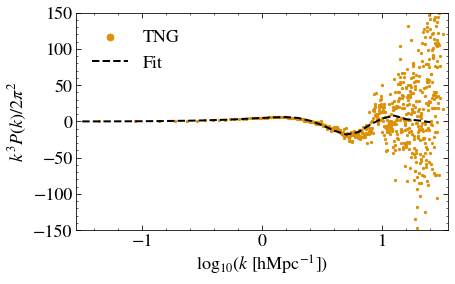

In [135]:
kcoef_tng = Pk10["k"]**3/(2*np.pi**2)
kcoef_fit = (10**np.array(logks))**3/(2*np.pi**2)
plt.scatter(np.log10(Pk10["k"]),kcoef_tng*(Pk10["power"].real-Pk10.attrs["shotnoise"]), s=5, label="TNG", c=palette_tab10[1])

plt.plot(logks, kcoef_fit*Pk,c="k", linestyle="dashed", label="Fit")
plt.ylabel(r"$k^3 P(k)/2\pi^2$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")

plt.ylim(-150,150)
plt.xlim(-1.55,1.55)
handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], markerscale=3)
#plt.savefig("../../figures/tng_exclusion_fit.pdf", format="pdf", bbox_inches="tight")


In [ ]:
def lognormal(r, sigma, R):
    fr = np.exp(-(np.log(r/R))**2/(2*sigma**2))/(r*sigma*np.sqrt(2*np.pi))
    return fr

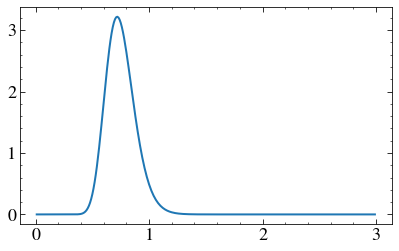

In [59]:
plt.plot(r, lognormal(r,sigma=0.17,R=0.74))

In [89]:
def pk_from_cf_no_lognormal(logks):
    rmax = 100
    dr=0.01
    r_list = np.arange(1e-4,rmax,dr)
    cf = cf_nl_excl(r_list, R=0.37, bias=2)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [90]:
Pk_no_lognormal = pk_from_cf_no_lognormal(logks)

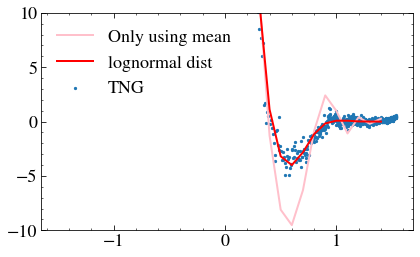

In [93]:
plt.plot(logks, Pk_no_lognormal,c="pink", label="Only using mean")
plt.scatter(np.log10(Pk10["k"]),Pk10["power"].real-Pk10.attrs["shotnoise"], s=5, label="TNG")
plt.plot(logks, Pk,c="red", label="lognormal dist")
plt.ylim(-10,10)
plt.legend()